# Formula :- Xi' = (xi - Xmin) / (Xmax - Xmin)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [13]:
df = pd.read_csv('wine_data.csv', header=None, usecols=[0,1,2])
df.columns = ["Class label","Alcohol","Malic acid"]

In [14]:
df.head()

,Class label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59


<Axes: xlabel='Alcohol', ylabel='Density'>

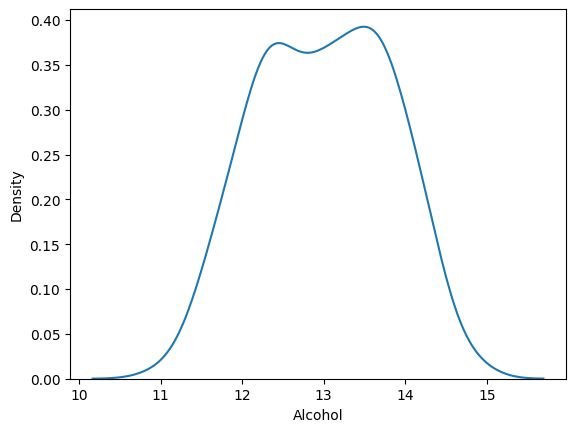

In [15]:
sns.kdeplot(df["Alcohol"])

<Axes: xlabel='Malic acid', ylabel='Density'>

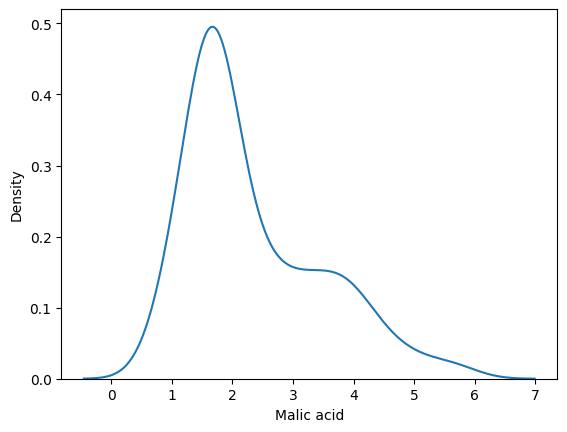

In [16]:
sns.kdeplot(df["Malic acid"])

<Axes: xlabel='Malic acid', ylabel='Alcohol'>

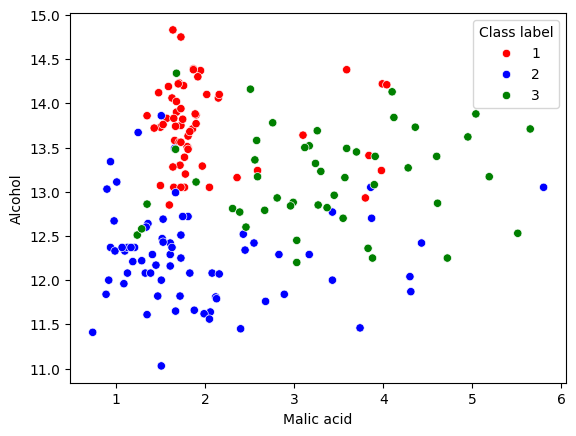

In [22]:
sns.scatterplot(x = "Malic acid", y = "Alcohol", data = df,hue = "Class label", palette= {1:"red",2:"Blue",3:"green"})

In [26]:
X = df.iloc[:,1:]
y = df["Class label"]

In [30]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [37]:
mms = MinMaxScaler()

In [38]:
mms.fit(X_train)

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [39]:
X_train_scaled = mms.transform(X_train)
X_test_scaled = mms.transform(X_test)

In [41]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [44]:
np.round(X_train_scaled.describe(), 1)

,Alcohol,Malic acid
count,142.0,142.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.3,0.1
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


## Effecting Data

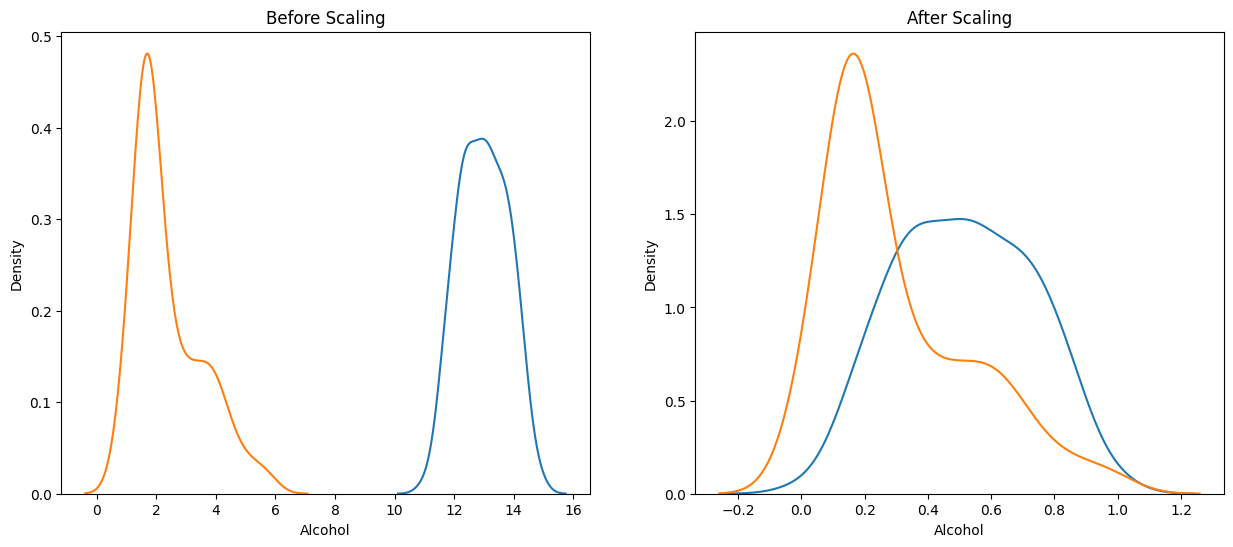

In [45]:
plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
plt.title("Before Scaling")
sns.kdeplot(X_train["Alcohol"])
sns.kdeplot(X_train["Malic acid"])

plt.subplot(1,2,2)
plt.title("After Scaling")
sns.kdeplot(X_train_scaled["Alcohol"])
sns.kdeplot(X_train_scaled["Malic acid"])

plt.show()

## Checking Data Give same Information or not

<Axes: title={'center': 'After Scaling'}, xlabel='Alcohol', ylabel='Malic acid'>

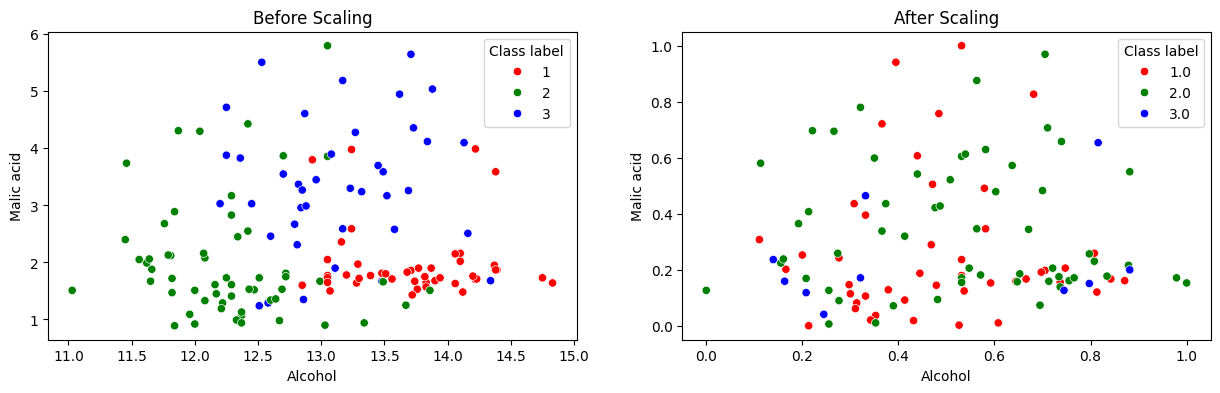

In [52]:
plt.figure(figsize=(15,4))

plt.subplot(1,2,1)
plt.title("Before Scaling")
sns.scatterplot(x = "Alcohol", y = "Malic acid", data = X_train, hue = y_train, palette={1:"red",2:"green",3:"blue"})

plt.subplot(1,2,2)
plt.title("After Scaling")
sns.scatterplot(x = "Alcohol", y = "Malic acid", data = X_train_scaled, hue = y_train, palette={1:"red",2:"green",3:"blue"})

## Alcohol Distribution Before and After Scaling

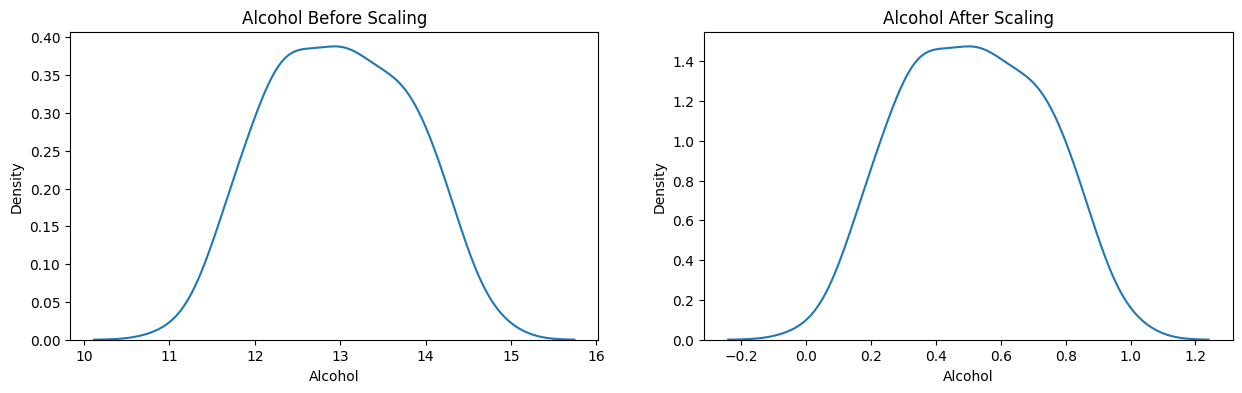

In [53]:
plt.figure(figsize=(15,4))

plt.subplot(1,2,1)
plt.title("Alcohol Before Scaling")
sns.kdeplot(X_train["Alcohol"])

plt.subplot(1,2,2)
plt.title("Alcohol After Scaling")
sns.kdeplot(X_train_scaled["Alcohol"])

plt.show()

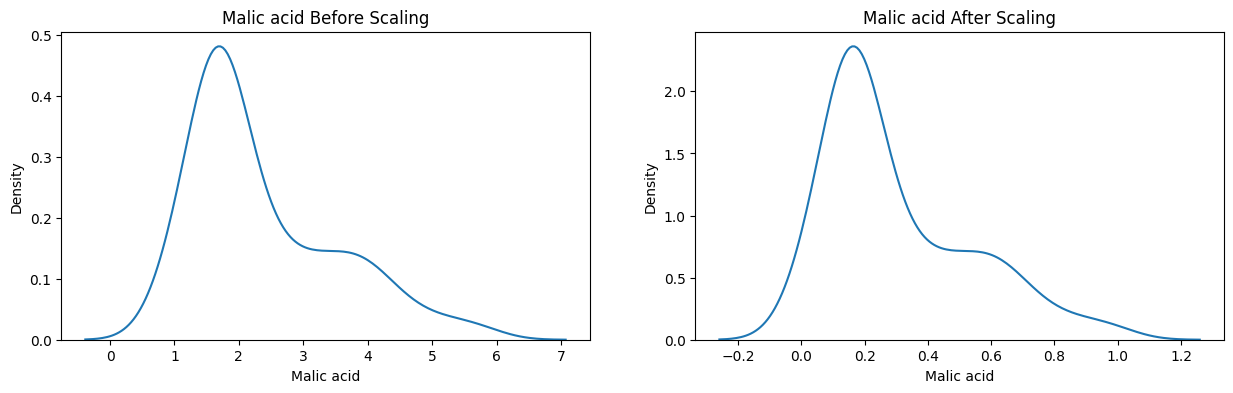

In [54]:
plt.figure(figsize=(15,4))

plt.subplot(1,2,1)
plt.title("Malic acid Before Scaling")
sns.kdeplot(X_train["Malic acid"])

plt.subplot(1,2,2)
plt.title("Malic acid After Scaling")
sns.kdeplot(X_train_scaled["Malic acid"])

plt.show()